In [1]:
import numpy as np
import nibabel as nib
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt 
import scipy
from nilearn.image import resample_to_img
from nilearn.input_data import NiftiSpheresMasker
from nibabel.affines import apply_affine
from functools import reduce
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.formula.api as smf
from scipy.signal import butter, filtfilt
import warnings
warnings.filterwarnings("ignore",
    message="Data array used to create a new image contains 64-bit ints",
    category=UserWarning)


<h1 align='center'>Preprocessed images</h1>

## SNR on unsmoothed images

In [ ]:

#--------------------------------- helper functions

def compute_mean_image(data: np.ndarray) -> np.ndarray:
    """
    Compute voxel‐wise mean over time of a 4D fMRI array.
    """
    return np.mean(data, axis=3)

def compute_std_image(data: np.ndarray) -> np.ndarray:
    """
    Compute voxel‐wise standard deviation over time of a 4D fMRI array.
    """
    return np.std(data, axis=3)

def create_nifti(img3d: np.ndarray,
                 affine: np.ndarray,
                 header: nib.Nifti1Header) -> nib.Nifti1Image:
    """
    Wrap a 3D array into a new NIfTI image, updating glmin/glmax.
    """
    hdr = header.copy()
    hdr['glmin'] = np.nanmin(img3d)
    hdr['glmax'] = np.nanmax(img3d)
    return nib.Nifti1Image(img3d.astype(img3d.dtype), affine, hdr)

def compute_spatial_snr(mean_data: np.ndarray, noise_std: float) -> np.ndarray:
    """Spatial SNR = mean / noise_std, returns int16."""
    with np.errstate(divide='ignore', invalid='ignore'):
        ssnr = mean_data / noise_std
        ssnr[np.isnan(ssnr) | np.isinf(ssnr)] = 0  # set problematic voxels to 0
    return ssnr.astype(np.int16)

def compute_temporal_snr(mean_data: np.ndarray,
                         std_data:  np.ndarray) -> np.ndarray:
    """Temporal SNR = mean / std (handles std==0)."""
    with np.errstate(divide='ignore', invalid='ignore'):
        tsnr = np.divide(mean_data, std_data,
                         out=np.zeros_like(mean_data, dtype=float),
                         where=std_data > 0)
    return tsnr.astype(np.int16)

def compute_nonbrain_noise_std(
        nii_fname: str,
        mean_data: np.ndarray,
        voxelsize: float,
        shape: tuple[int, int, int],
        radius_mm: float = 5,
        offset_mm: float = 18,
        pct_fallback: float = 2.0
) -> float:
    """
    Try corner sphere first; if std==0 fall back to darkest `pct_fallback`%
    of voxels inside the volume.
    """
    from nibabel.affines import apply_affine
    img     = nib.load(nii_fname)
    affine  = img.affine

    # ― try corner sphere ―
    adj_vox   = int(round(offset_mm / voxelsize))
    seed_vox  = np.array(shape) - adj_vox
    seed_mm   = apply_affine(affine, seed_vox)

    masker = NiftiSpheresMasker(seeds=[seed_mm], radius=radius_mm,
                                mask_img=None, allow_overlap=True)
    try:
        ts = masker.fit_transform(nii_fname)
        std = float(np.std(ts))
    except ValueError:
        std = 0.0

    # ― fall back if sphere had zero or near-zero variance ―
    if std < 1e-6:
        flat    = mean_data.ravel()
        thr     = np.percentile(flat, pct_fallback)
        std     = float(np.std(flat[flat <= thr]))
        print(f"[noise] fallback to darkest {pct_fallback}% voxels (thr={thr:.2f})")

    return std

def nii2mosaic(img3d: np.ndarray,
               out_png: str,
               cmap: str = 'gray',
               cond: str = None) -> None:
    """
    Make a sqrt‐grid mosaic of the slices in img3d and save to out_png.
    """
    z = img3d.shape[2]
    cols = int(np.ceil(np.sqrt(z)))
    rows = int(np.ceil(z / cols))
    h, w = img3d.shape[0], img3d.shape[1]

    # prepare empty canvas
    mosaic = np.zeros((h * rows, w * cols), dtype=img3d.dtype)

    idx = 0
    for r in range(rows):
        for c in range(cols):
            if idx >= z:
                break
            slice_ = img3d[:, :, idx]     # no rotation, keeps shape (h, w)
            mosaic[r*h:(r+1)*h, c*w:(c+1)*w] = slice_
            idx += 1

    # auto‐threshold for special conditions
    flat = mosaic.ravel()
    if cond == 'variance':
        hist, bins = np.histogram(flat, bins=1000)
        peaks = np.where(hist > 400)[0]
        vmax = bins[peaks[-1]] if peaks.size else flat.max()
    elif cond == 'diff':
        hist, bins = np.histogram(flat, bins=50, density=True)
        vmax = bins[5] if bins.size > 5 else flat.max()
    else:
        vmax = flat.max()

    plt.figure(figsize=(cols*2, rows*2), dpi=300)
    plt.imshow(mosaic, cmap=cmap, vmax=vmax)
    plt.axis('off')
    plt.savefig(out_png, bbox_inches='tight', pad_inches=0)
    plt.close()

#--------------------------------- main script

prepr_dir = f'../data/preprocessed/fmri'
sub_dirs  = sorted(glob.glob(f'{prepr_dir}/sub-*'))
for sub_dir in sub_dirs:

    sub_id = os.path.basename(sub_dir)
    print(f'Processing {sub_id}...')

    nii_fname = f'{sub_dir}/func/func.nii'
    rp_fname  = f'{sub_dir}/func/rp.txt'
    out_dir   = f'{sub_dir}/qc'
    os.makedirs(out_dir, exist_ok=True)

    #------------------------------------- load data

    nii       = nib.load(nii_fname)
    header    = nii.header
    affine    = nii.affine
    voxelsize = nii.header['pixdim'][1]
    data      = nii.get_fdata()
    shape     = data.shape[:3] # spatial dimensions
    nrvoxel   = shape[0] * shape[1] * shape[2]
    nrvolumes = data.shape[-1] # temporal dimension

    print(f' - Voxel size: {voxelsize} mm')
    print(f' - Shape: {shape}')
    print(f' - Number of voxels: {nrvoxel}')
    print(f' - Number of volumes: {nrvolumes}')

    #------------------------------------- compute mean and std images

    mean_data = compute_mean_image(data)
    std_data  = compute_std_image(data)
    mean_img  = create_nifti(mean_data, affine, header)
    std_img   = create_nifti(std_data, affine, header)
    nib.save(mean_img, f'{out_dir}/mean.nii.gz')
    nii2mosaic(mean_data, f'{out_dir}/mean.png', cond='mean')
    nib.save(std_img,  f'{out_dir}/std.nii.gz')
    nii2mosaic(std_data, f'{out_dir}/std.png', cond='mean')

    #------------------------------------- compute spatial and temporal SNR images

    noise_std = compute_nonbrain_noise_std(nii_fname, mean_data, voxelsize, shape, 
                                           radius_mm=5, offset_mm=18)
    ssnr_data = compute_spatial_snr(mean_data, noise_std)
    ssnr_img  = create_nifti(ssnr_data, affine, header)
    nib.save(ssnr_img, f'{out_dir}/ssnr.nii.gz')
    nii2mosaic(ssnr_data, f'{out_dir}/ssnr.png', cond='mean')

    tsnr_data = compute_temporal_snr(mean_data, std_data)
    tsnr_img  = create_nifti(tsnr_data, affine, header)
    nib.save(tsnr_img, f'{out_dir}/tsnr.nii.gz')
    nii2mosaic(tsnr_data, f'{out_dir}/tsnr.png', cond='mean')

    #------------------------------------- compute SNR per ROI

    atlas_dir  = f'../Masks/atlases'
    n_schaefer = 100
    roi_pkl    = pd.read_pickle(f'{atlas_dir}/Schaefer100_HO-subcort25_1mm.pkl')
    atlas_img  = roi_pkl['image']
    roi_dict   = roi_pkl['rois']

    # resample atlas to match the functional image resolution
    atlas_res  = resample_to_img(atlas_img, tsnr_img, interpolation='nearest', 
                                 copy_header=True, force_resample=True)
    atlas_data = atlas_res.get_fdata().astype(np.int32)

    rows = []
    for roi_ix, roi_label in roi_dict.items():

        roi_mask = atlas_data == roi_ix
        if not np.any(roi_mask):
            continue  # skip empty labels
        
        vals_t = tsnr_data[roi_mask]
        vals_s = ssnr_data[roi_mask]
        
        rows.append({
            'roi':         roi_label,
            'tsnr_mean':   np.mean(vals_t),
            'tsnr_median': np.median(vals_t),
            'tsnr_std':    np.std(vals_t),
            'ssnr_mean':   np.mean(vals_s),
            'ssnr_median': np.median(vals_s),
            'ssnr_std':    np.std(vals_s),
            'n_voxels':    int(roi_mask.sum())
        })

    df = pd.DataFrame(rows)
    df.to_excel(f'{out_dir}/snr_per_roi.xlsx', index=False)

Processing sub-01...
 - Voxel size: 3.0 mm
 - Shape: (53, 63, 52)
 - Number of voxels: 173628
 - Number of volumes: 784
[noise] fallback to darkest 2.0% voxels (thr=0.00)
Processing sub-02...
 - Voxel size: 3.0 mm
 - Shape: (53, 63, 52)
 - Number of voxels: 173628
 - Number of volumes: 784
[noise] fallback to darkest 2.0% voxels (thr=0.00)
Processing sub-03...
 - Voxel size: 3.0 mm
 - Shape: (53, 63, 52)
 - Number of voxels: 173628
 - Number of volumes: 784
[noise] fallback to darkest 2.0% voxels (thr=0.00)
Processing sub-05...
 - Voxel size: 3.0 mm
 - Shape: (53, 63, 52)
 - Number of voxels: 173628
 - Number of volumes: 782
[noise] fallback to darkest 2.0% voxels (thr=0.00)
Processing sub-06...
 - Voxel size: 3.0 mm
 - Shape: (53, 63, 52)
 - Number of voxels: 173628
 - Number of volumes: 784
[noise] fallback to darkest 2.0% voxels (thr=0.00)
Processing sub-07...
 - Voxel size: 3.0 mm
 - Shape: (53, 63, 52)
 - Number of voxels: 173628
 - Number of volumes: 784
[noise] fallback to darke

In [6]:
prepr_dir = f'../data/preprocessed/fmri'
pattern   = os.path.join(prepr_dir, 'sub-*', 'qc', 'snr_per_roi.xlsx')

records = []
for fp in glob.glob(pattern):
    # read in the ROI table
    df = pd.read_excel(fp)
    # filter for Left Hippocampus
    row = df.loc[df['roi'] == 'Left Hippocampus', 'tsnr_mean']
    tsnr = row.iloc[0] if not row.empty else float('nan')
    # extract sub-XX folder name and strip off "sub-"
    sub_folder = os.path.basename(os.path.dirname(os.path.dirname(fp)))
    sub_id     = sub_folder.replace('sub-', '')
    records.append({'sub_id': sub_id,
                    'tsnr': tsnr})

# assemble and write out
master_df = pd.DataFrame(records)
master_df.to_excel(f'../data/quality-control/L-HPC_tsnr.xlsx', index=False)

## Framewise displacement from motion parameters

In [ ]:
def calc_fd(mov,
            radius_mm: float = 50.0,
            filter_respiratory: bool = False,
            tr_s: float = 2.0,
            diff_tr: int = 1,
            stopband: tuple = (0.2, 0.5),
            filter_order: int = 10):
    """
    Compute framewise displacement (FD) under SPM conventions,
    with optional respiratory filtering and multi-TR differencing.

    Parameters
    ----------
    mov : array-like, shape (n_vols, 6) or DataFrame
        SPM realignment parameters [X(mm), Y(mm), Z(mm), RotX(rad), RotY(rad), RotZ(rad)].
    radius_mm : float
        Sphere radius (mm) to convert rotations → mm.
    filter_respiratory : bool
        If True, apply a stop-band Butterworth filter to suppress respiration (0.2–0.5 Hz).
        NOTE: Explicit respiratory filtering or regression really only becomes critical once your TR is fast enough (<≈1 s) 
        that respiratory motion is no longer aliased and instead appears as a constant high-frequency “noise” in your unfiltered FD trace.
    tr_s : float
        Repetition time (s), used to compute Nyquist and normalize filter.
    diff_tr : int
        Number of TRs over which to difference for FD. (1 for standard FD, 4 for ~2.9 s FD)
    stopband : (low, high)
        Respiratory stop-band frequencies (Hz) to suppress.
    filter_order : int
        Order of the Butterworth filter.

    Returns
    -------
    fd : ndarray, shape (n_vols,)
        Framewise displacement (mm), with fd[0:diff_tr] = 0.
    """
    # Handle DataFrame input
    if isinstance(mov, pd.DataFrame):
        mov = mov.values
    mov = np.asarray(mov, dtype=float)
    n_vols, n_cols = mov.shape
    if n_cols != 6:
        raise ValueError(f"Expected 6 realignment columns, got {n_cols}")

    # Heuristic unit check
    # unit check (warn if translations >> mm or rotations >> rad)
    def _infer_spm_units(mov, tol_trans=20.0, tol_rot=0.5):
        if np.nanmax(np.abs(mov[:, :3])) > tol_trans:
            warnings.warn("Translations look >20 mm; check units.")
        if np.nanmax(np.abs(mov[:, 3:])) > tol_rot:
            warnings.warn("Rotations look >0.5 rad; check units.")
    _infer_spm_units(mov)

    # Convert rotations (rad) → mm
    disp = np.hstack((mov[:, :3], mov[:, 3:6] * radius_mm))

    # Respiratory filtering
    if filter_respiratory:
        fs  = 1.0 / tr_s
        nyq = fs / 2.0
        low, high = stopband
        if high >= nyq:
            warnings.warn(
                f"Requested stopband {low:.2f}–{high:.2f} Hz exceeds Nyquist "
                f"{nyq:.2f} Hz (TR={tr_s}s); skipping respiratory filter."
            )
        else:
            Wn = [low/nyq, high/nyq]
            b, a = butter(filter_order, Wn, btype='stop', analog=False)
            filtered = np.zeros_like(disp)
            for i in range(disp.shape[1]):
                filtered[:, i] = filtfilt(b, a, disp[:, i])
            disp = filtered

    # Multi-TR differencing
    if diff_tr > 1:
        zeros = np.zeros((diff_tr, disp.shape[1]))
        diffs = np.vstack((zeros, disp[diff_tr:] - disp[:-diff_tr]))
    else:
        diffs = np.vstack((np.zeros((1, disp.shape[1])), np.diff(disp, axis=0)))

    # Sum of absolute displacements
    fd = np.sum(np.abs(diffs), axis=1)
    return fd

def get_decision_fd(fd, tr_s=1):
        
        n_vols = len(fd)
        n_dec_vols = 12 / tr_s # number of volumes in a decision trial (12 sec / TR)
        vol_centers = (np.arange(n_vols) + 0.5) * tr_s # compute the time (in sec) at the CENTER of each volume
        trial_fd = []
        for i, trial in decision_trials.iterrows():
                mask    = (vol_centers >= trial['fmri_onset']) & (vol_centers < trial['fmri_offset']) # find volumes whose center falls within [onset, offset)
                fd_vals = fd[np.where(mask)[0]]
                assert len(fd_vals) == n_dec_vols, f"Expected {n_dec_vols} volumes, got {len(fd_vals)} for trial {trial['trial_id']}"
                fd_trial = np.nanmean(fd_vals)
                trial_fd.append((i + 1, fd_trial))
        fd_df = pd.DataFrame(trial_fd, columns=['decision_num', 'mean_fd'])
        return fd_df

preprc_dir  = f'../data/preprocessed/fmri/subs'
folders = glob.glob(f'{preprc_dir}/*')
sub_ids = [int(f.split('/')[-1].split('-')[1]) for f in folders if 'sub-' in f.split('/')[-1]]

sub_results = []
for sub_id in tqdm(sub_ids):

    # load the realignment parameters
    rp_file = f'{preprc_dir}/sub-{sub_id:02d}/func/rp.txt'
    rp = pd.read_csv(rp_file, header=None, delim_whitespace=True)
    if rp.shape[1] != 6: # load in another way
        rp = pd.read_csv(rp_file, header=None, delim_whitespace=False)

    if len(str(sub_id)) > 2: 
         tr_s    = 1.0
         diff_tr = 1
         filter_respiratory = False
    else:
         tr_s    = 2.0
         diff_tr = 1
         filter_respiratory = False

    # compute volume-wise fd
    fd = calc_fd(rp, tr_s=tr_s, diff_tr=diff_tr, filter_respiratory=filter_respiratory)

    # get decision trials fd
    decision_fd = get_decision_fd(fd, tr_s=tr_s)
    decision_fd.to_excel(f'../data/quality-control/framewise-displacement/sub-{sub_id:02d}_fd.xlsx', index=False)

    # summary statistics
    mean_fd = np.nanmean(fd)
    sub_results.append((sub_id, mean_fd))
sub_fd = pd.DataFrame(sub_results, columns=['sub_id', 'mean_fd'])
sub_fd.to_excel('../data/quality-control/motion_fd.xlsx', index=False)

100%|██████████| 95/95 [00:00<00:00, 143.92it/s]


<h1 align='center'>GLM images</h1>

## Visualize brain masks

In [ ]:
fmri_data_dir = '../data/fmri/'
lsa_dir = f'{base_dir}/analyses/lsa_decision/lsa_images'
mask_imgs = glob.glob(f'{lsa_dir}/*mask*')
print(f'Found {len(mask_imgs)} mask images')

out_dir = f'{base_dir}/data/QC/mask_coverage'
for img in mask_imgs:
    sub_id = int(img.split('/')[-1].split('_')[0])
    # from nilearn.plotting import plot_anat

    nilearn.plotting.plot_roi(img, display_mode='mosaic', draw_cross=False, title=sub_id)
    plt.savefig(f'{out_dir}/{sub_id}.png')
    plt.close()

## Check for number of voxels in searchlights

/var/folders/6j/97qtbfv55979kc8p1nz6008r0000gn/T/ipykernel_94676/2444111587.py:59: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mni_resamp = image.resample_to_img(mni_mask_img, nib.Nifti1Image(good3d.astype(np.uint8), affine),
/Users/matty_gee/miniconda3/envs/trajectories/lib/python3.11/site-packages/nilearn/image/resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(



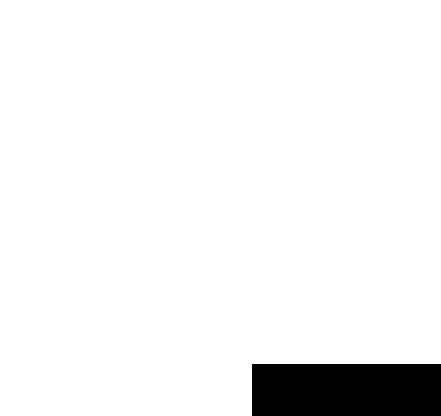
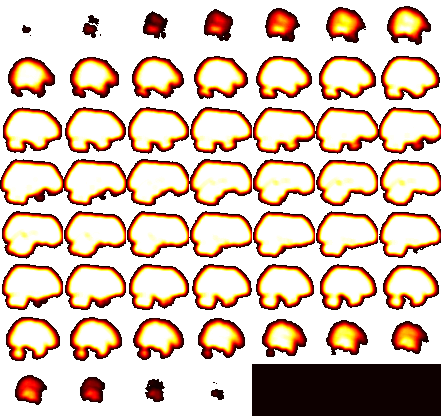

In [19]:
import numpy as np
import nibabel as nib
from pathlib import Path
from scipy.ndimage import convolve
from nilearn import datasets, image, plotting

def active_prop_summary(
    img,
    *,
    shape: str = "ball",          # 'ball' | 'diamond' | 'cube'
    radius: int = 3,
    good_rule: str = "all",       # 'all' | 'any' | 'prop>=p' (e.g., 'prop>=0.9')
    roi_mask=None,                # optional 3D mask (array, NIfTI, or path)
    use_mni_mask: bool = True,  
    min_props=(0.01, 0.05, 0.10, 0.20),
    return_maps: bool = False
):
    """
    Compute a voxelwise map of the fraction of 'active' voxels in each searchlight neighborhood,
    then summarize coverage for several min_prop thresholds. If use_mni_mask=True, restrict
    analysis to the MNI152 brain mask (resampled to the data).
    """
    # ---------- load data ----------
    if isinstance(img, (str, Path)):
        nii = nib.load(str(img))
        img4d = nii.get_fdata(dtype=np.float32)
        affine = nii.affine
    elif isinstance(img, nib.spatialimages.SpatialImage):
        img4d = img.get_fdata(dtype=np.float32)
        affine = img.affine
    elif isinstance(img, np.ndarray):
        img4d = img.astype(np.float32, copy=False)
        affine = np.eye(4)
    else:
        raise TypeError("img must be ndarray, NIfTI image, or path")

    if img4d.ndim != 4:
        raise ValueError(f"Expected 4D (X,Y,Z,T); got {img4d.shape}")
    X, Y, Z, T = img4d.shape

    # ---------- collapse time to a 3D "good" mask ----------
    ok = (~np.isnan(img4d)) & (img4d != 0)
    if good_rule == "all":
        good3d = ok.all(axis=3)
    elif good_rule == "any":
        good3d = ok.any(axis=3)
    elif good_rule.startswith("prop>="):
        p = float(good_rule.split(">=")[1])
        good3d = (ok.sum(axis=3) >= p * T)
    else:
        raise ValueError("good_rule must be 'all', 'any', or 'prop>=p'")

    # ---------- restrict with ROI and/or MNI mask ----------
    support_mask = np.ones((X, Y, Z), dtype=bool)

    if use_mni_mask:
        # nilearn's canonical brain mask; resample to the functional/grid of your img
        mni_mask_img = datasets.load_mni152_brain_mask()  # 2mm template mask
        mni_resamp = image.resample_to_img(mni_mask_img, nib.Nifti1Image(good3d.astype(np.uint8), affine),
                                           interpolation="nearest")
        support_mask &= mni_resamp.get_fdata().astype(bool)

    if roi_mask is not None:
        if isinstance(roi_mask, (str, Path)):
            roi_mask = nib.load(str(roi_mask))
        if isinstance(roi_mask, nib.spatialimages.SpatialImage):
            roi_resamp = image.resample_to_img(roi_mask, nib.Nifti1Image(good3d.astype(np.uint8), affine),
                                               interpolation="nearest")
            roi_arr = roi_resamp.get_fdata().astype(bool)
        else:
            roi_arr = np.asarray(roi_mask, bool)
            if roi_arr.shape != (X, Y, Z):
                raise ValueError(f"ROI mask shape {roi_arr.shape} != {(X, Y, Z)}")
        support_mask &= roi_arr

    good3d = (good3d & support_mask).astype(np.float32)

    # ---------- neighborhood footprint ----------
    r = int(radius)
    xs, ys, zs = np.ogrid[-r:r+1, -r:r+1, -r:r+1]
    if shape == "ball":
        footprint = (xs*xs + ys*ys + zs*zs) <= r*r
    elif shape == "diamond":
        footprint = (np.abs(xs) + np.abs(ys) + np.abs(zs)) <= r
    elif shape == "cube":
        footprint = np.ones((2*r+1, 2*r+1, 2*r+1), dtype=bool)
    else:
        raise ValueError("shape must be 'ball', 'diamond', or 'cube'")
    footprint = footprint.astype(np.float32)
    S = int(footprint.sum())

    # ---------- compute active proportion per center ----------
    counts = convolve(good3d, footprint, mode="constant", cval=0.0)
    prop_map = (counts / S).astype(np.float32)

    # only summarize within support
    vals = prop_map[support_mask]
    n_total = int(np.prod(prop_map.shape))
    n_support = int(support_mask.sum())

    if n_support == 0:
        coverage = {float(p): 0.0 for p in min_props}
        p10 = p50 = p90 = float("nan")
    else:
        coverage = {float(p): float((vals >= p).mean()) for p in min_props}
        p10, p50, p90 = (float(np.percentile(vals, q)) for q in (10, 50, 90))

    summary = {
        "shape": shape,
        "radius": r,
        "footprint_size": S,
        "n_voxels_support": n_support,
        "support_fraction_of_volume": n_support / n_total,
        "prop_p10": p10,
        "prop_median": p50,
        "prop_p90": p90,
        "coverage_by_min_prop": coverage,  # fractions in [0,1]
        "used_mni_mask": bool(use_mni_mask),
    }

    if return_maps:
        return summary, nib.Nifti1Image(prop_map, affine), nib.Nifti1Image(support_mask.astype(np.uint8), affine)
    return summary

def view_active_prop(prop_map_img, other_prop_map_img=None, bg_img=None, title=None):
    """Interactive viewer for the proportion map (or a difference map if 'other' is provided)."""
    if other_prop_map_img is not None:
        A = prop_map_img.get_fdata(dtype=np.float32)
        B = other_prop_map_img.get_fdata(dtype=np.float32)
        img = nib.Nifti1Image(B - A, prop_map_img.affine)
        ttl = title or "Difference map: other - first"
    else:
        img = prop_map_img
        ttl = title or "Active proportion map"
    return plotting.view_img(img, bg_img=bg_img, title=ttl)


img_fname = '/Users/matty_gee/Desktop/SocialTrajectories/analyses/original/lsa_rt/glms/sub-01/beta_decisions.nii.gz'
summary_ball, prop_ball, sup = active_prop_summary(
   img_fname,
    shape="ball",
    radius=3,
    good_rule="prop>=0.9",          # choose 'all', 'any', or a proportion rule
    min_props=(0.10, 0.20, 0.50),
    return_maps=True
)
view_active_prop(prop_ball)

<h1 align='center'>Searchlight images</h1>